In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
train=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Train_Cleaned (4).csv")

In [4]:
val=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Validation_Cleaned (3).csv")

## Data Spliting


In [5]:
# Define the features and the target
X_train = train.drop(['Reservation-id', 'Reservation_Status', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_train = train['Reservation_Status']

X_val = val.drop(['Reservation-id', 'Reservation_Status','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_val = val['Reservation_Status']


## Feature scaling

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fitting on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame for easier handling (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("Scaling complete")

Scaling complete


## Model Training


In [8]:
from sklearn.ensemble import RandomForestClassifier

# finding the best 15 columns
selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X_train_scaled, y_train)

# Filtering
indices = np.argsort(selector.feature_importances_)[::-1][:15]
top_features = X_train_scaled.columns[indices].tolist()

X_train_final = X_train_scaled[top_features]
X_val_final = X_val_scaled[top_features]


print("Selected Features:", top_features)

Selected Features: ['Lead_Time', 'Room_Rate', 'Age', 'Checkin_Month', 'Total_Guests', 'Discount_Rate', 'Length_of_Stay', 'Meal_Type_fb', 'Gender_m', 'Required_Car_Parking_yes', 'Country_region_south', 'Hotel_Type_city hotel', 'Booking_channel_online', 'Visted_Previously_yes', 'Income_50k -- 100k']


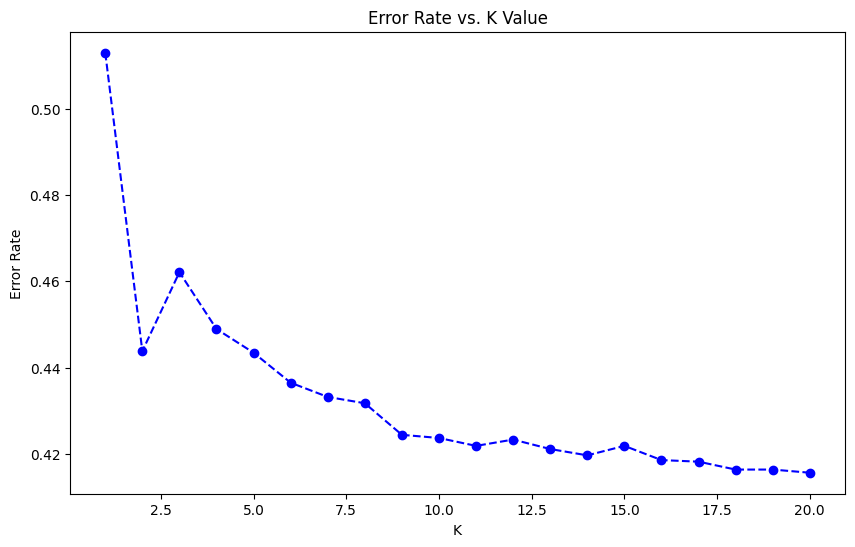

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Testing K from 1 to 20
error_rate = []
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_final, y_train)
    pred_i = knn.predict(X_val_final)
    error_rate.append(np.mean(pred_i != y_val))

# Plotting the results
plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use K=17 based on your Elbow Graph
knn_final = KNeighborsClassifier(n_neighbors=17, weights='distance')

# Train on your final scaled data
knn_final.fit(X_train_final, y_train)

# Predict on the validation set
y_pred_knn = knn_final.predict(X_val_final)

# Results
print(f"KNN Accuracy with K=17: {accuracy_score(y_val, y_pred_knn):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

KNN Accuracy with K=17: 57.85%

Classification Report:
              precision    recall  f1-score   support

           1       0.58      0.98      0.73      1602
           2       0.23      0.01      0.03       738
           3       0.00      0.00      0.00       393

    accuracy                           0.58      2733
   macro avg       0.27      0.33      0.25      2733
weighted avg       0.41      0.58      0.44      2733

